In [1]:
import sys
import os

sys.path.append(os.path.abspath('..'))
from src.data import get_sql_data


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = get_sql_data()  

In [7]:
print(f'Shape: {df.shape}')
print(f'Dtypes:\n{df.dtypes}')

Shape: (96353, 20)
Dtypes:
order_id                    object
review_score                 int64
bad_score                    int64
num_items                    int64
total_price                float64
total_freight              float64
freight_ratio              float64
name_len                     int64
desc_len                     int64
category                    object
prod_photos                  int64
weight_g                     int64
volume_l                   float64
has_missing_details          int64
delivery_days              float64
estimated_delivery_diff    float64
seller_disp_diff           float64
processing_days            float64
is_seller_late               int64
is_delivery_late             int64
dtype: object


In [5]:
df.drop(['bad_score', 'has_missing_details','is_seller_late', 'is_delivery_late'], axis=1)\
    .describe()

,review_score,num_items,total_price,total_freight,freight_ratio,name_len,desc_len,prod_photos,weight_g,volume_l,delivery_days,estimated_delivery_diff,seller_disp_diff,processing_days
count,96353.000000,96353.000000,96353.000000,96353.000000,96353.000000,96353.000000,96353.000000,96353.000000,96353.000000,96353.000000,96353.000000,96353.000000,96352.000000,96338.000000
mean,4.155688,1.141687,136.654623,22.757810,0.308616,48.197804,782.424024,2.218115,2105.417309,15.191844,12.058472,-10.996720,-2.950774,2.305124
std,1.284979,0.535362,207.444085,21.496018,0.311694,11.456528,655.898368,1.753206,3760.426753,23.302879,9.462698,9.951195,4.930621,3.513205
min,1.000000,1.000000,0.850000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-146.000000,-1046.000000,-171.000000
25%,4.000000,1.000000,45.900000,13.840000,0.132100,42.000000,341.000000,1.000000,300.000000,2.820000,6.000000,-16.000000,-5.000000,0.000000
50%,5.000000,1.000000,86.000000,17.160000,0.224500,52.000000,600.000000,1.000000,700.000000,6.400000,10.000000,-11.000000,-3.000000,1.000000
75%,5.000000,1.000000,149.900000,23.990000,0.380800,57.000000,988.000000,3.000000,1813.000000,18.380000,15.000000,-6.000000,-1.000000,3.000000
max,5.000000,21.000000,13440.000000,1794.960000,21.447100,76.000000,3992.000000,20.000000,40425.000000,296.210000,208.000000,188.000000,116.000000,125.000000


In [20]:
print('NA count: ', df.isna().sum(), sep='\n')
print('Duplicates: ', df.duplicated(subset=['order_id']).sum())

NA count: 
order_id                    0
review_score                0
bad_score                   0
num_items                   0
total_price                 0
total_freight               0
freight_ratio               0
name_len                    0
desc_len                    0
category                    0
prod_photos                 0
weight_g                    0
volume_l                    0
has_missing_details         0
delivery_days               0
estimated_delivery_diff     0
seller_disp_diff            1
processing_days            15
is_seller_late              0
is_delivery_late            0
dtype: int64
Duplicates:  529


In [21]:
df_clean = df.dropna(axis=0) \
    .drop_duplicates(subset=['order_id'], keep='last').copy()

We can see that the review score distribution is not balanced - only about 21% of reviews are considered to benegative (1, 2 and 3 stars).

In [27]:
round(df_clean['review_score'].value_counts(normalize=True),3)

review_score
5    0.592
4    0.197
1    0.098
3    0.083
2    0.030
Name: proportion, dtype: float64

Normalizing total_price and total_freight columns do to their ditributions' skewness using log transformation

In [86]:
df_clean['log_total_price'] = np.log1p(df_clean['total_price'])
df_clean['log_total_freight'] = np.log1p(df_clean['total_freight'])

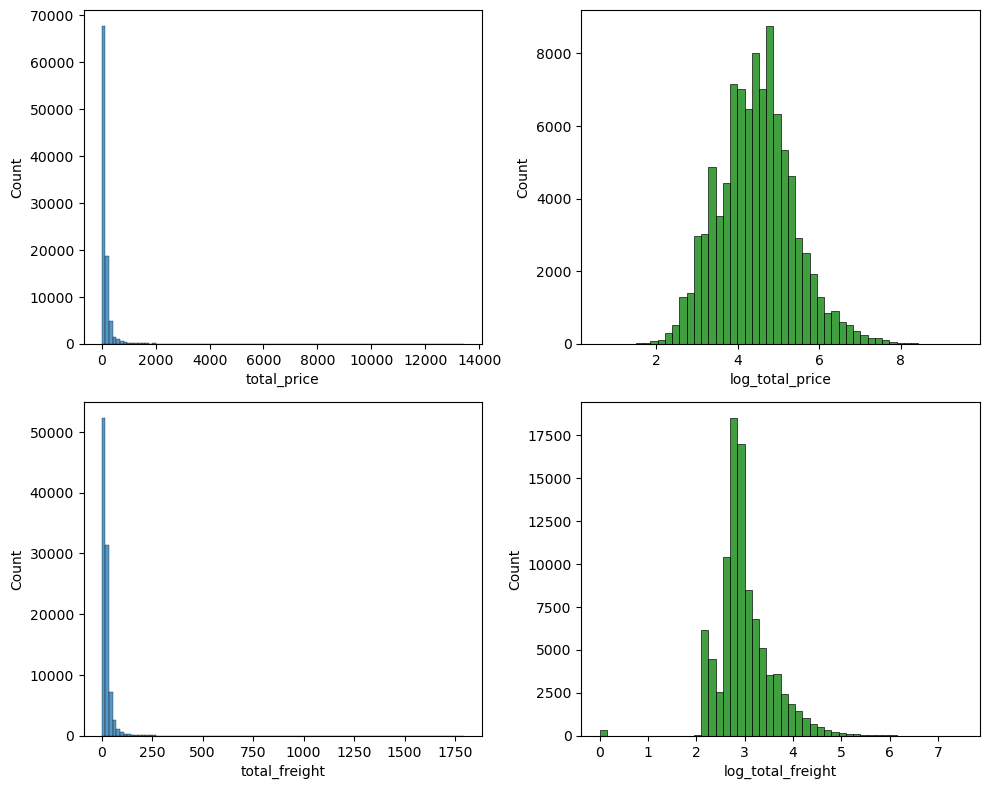

In [88]:
fig, ax = plt.subplots(nrows=2, ncols=2)
fig.set_figheight(8)
fig.set_figwidth(10)
sns.histplot(x=df_clean['total_price'], bins=100, ax=ax[0,0])
sns.histplot(x=df_clean['log_total_price'], bins=50, ax=ax[0,1], color='green')

sns.histplot(x=df_clean['total_freight'], bins=100, ax=ax[1,0])
sns.histplot(x=df_clean['log_total_freight'], bins=50, ax=ax[1,1], color='green')
plt.tight_layout()
plt.show()


In [121]:
df_clean.groupby('category')['review_score'].count().sort_values(ascending=False)[:10]

category
bed_bath_table           9081
health_beauty            8567
sports_leisure           7446
computers_accessories    6480
furniture_decor          6139
housewares               5646
watches_gifts            5436
telephony                4048
auto                     3774
toys                     3757
Name: review_score, dtype: int64

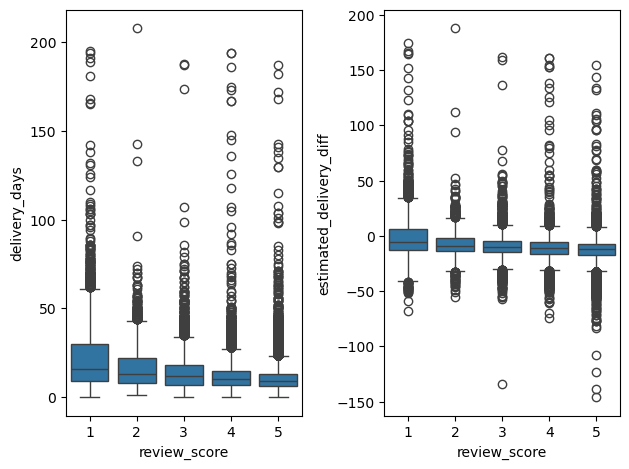

In [97]:
fig2, ax2 = plt.subplots(nrows=1, ncols=2)

ax2[0] = sns.boxplot(x='review_score', y='delivery_days', data=df_clean, ax=ax2[0])
ax2[1] = sns.boxplot(x='review_score', y='estimated_delivery_diff', data=df_clean, ax=ax2[1])
#ax2[2] = sns.boxplot(y='estimated_delivery_diff', data=df_clean, ax=ax2[2])
plt.tight_layout()

plt.show()

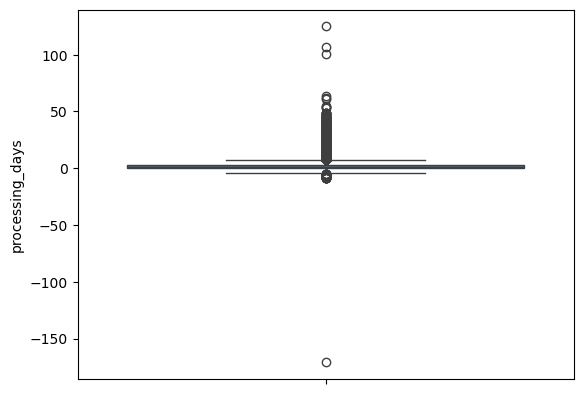

In [69]:
sns.boxplot(df_clean['processing_days'])
plt.show()

In [ ]:
df_clean.loc[df_clean['processing_days'] < 0 ,'processing_days'] = 0 

In [ ]:
lower_seller = df_clean['seller_disp_diff'].quantile(0.001)
print(f'0,1 th delivery_days percentile: {lower_seller}')
print(df_clean.loc[df_clean['seller_disp_diff'] < lower_seller, 'review_score'].value_counts(normalize=True),'\n')

lower_estimated = df_clean['estimated_delivery_diff'].quantile(0.001)
print(f'0,1 th delivery_days percentile: {lower_estimated}')
print(df_clean.loc[df_clean['estimated_delivery_diff'] < lower_estimated, 'review_score'].value_counts(normalize=True),'\n')

In [ ]:
upper_delivery = df_clean['delivery_days'].quantile(0.999)
print(f'99,9th delivery_days percentile: {upper_delivery}')
print(df_clean.loc[df_clean['delivery_days'] >= upper_delivery, 'review_score'].value_counts(normalize=True),'\n')

upper_estimated = df_clean['estimated_delivery_diff'].quantile(0.999)
print(f'99,9th estimated_delivery_diff percentile: {upper_estimated}')
print(df_clean.loc[df_clean['estimated_delivery_diff'] >= upper_estimated, 'review_score'].value_counts(normalize=True),'\n')

upper_processing = df_clean['processing_days'].quantile(0.999)
print(f'99,9th processing_days percentile: {upper_processing}')
print(df_clean.loc[df_clean['processing_days'] >= upper_processing, 'review_score'].value_counts(normalize=True),'\n')

upper_seller = df_clean['seller_disp_diff'].quantile(0.999)
print(f'99,9th seller_disp_diff percentile: {upper_seller}')
print(df_clean.loc[df_clean['seller_disp_diff'] < upper_seller, 'review_score'].value_counts(normalize=True))


In [109]:
df_transformed = df_clean.drop(['order_id'], axis=1).copy()

In [79]:
df_transformed['delivery_days'] = df_clean['delivery_days'].clip(upper=upper_delivery)
df_transformed['estimated_delivery_diff'] = df_clean['estimated_delivery_diff'].clip(lower = lower_estimated, upper = upper_estimated)
df_transformed['processing_days'] = df_clean['processing_days'].clip(upper = upper_processing)
df_transformed['seller_disp_diff'] = df_clean['seller_disp_diff'].clip(lower = lower_seller, upper = upper_seller)

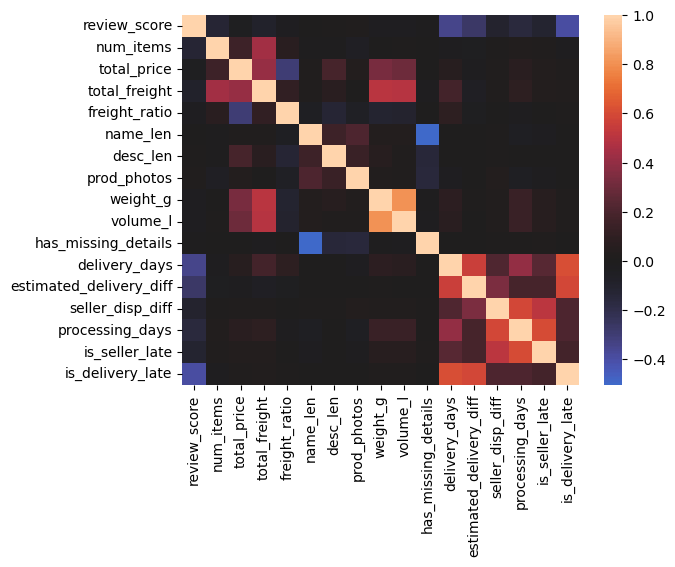

In [80]:
g = sns.heatmap(df_transformed.drop(['bad_score'], axis=1).corr(numeric_only=True), center= 0)
plt.show()

In [137]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold, RFECV
from sklearn.model_selection import train_test_split, StratifiedKFold


In [122]:
X = df_transformed.drop(['review_score', 'bad_score'], axis=1) # 'order_id', 'category'
y = df_transformed['bad_score'] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=123)

In [123]:
from category_encoders import TargetEncoder

In [158]:
encoder = TargetEncoder(cols=['category'], smoothing=10)
X_train_encoded = encoder.fit_transform(X_train, y_train)

In [181]:
rf = RandomForestClassifier(n_estimators=100, max_depth=5, n_jobs=-1, random_state=123, class_weight='balanced')

#rf.fit(X_train_encoded, y_train)

In [133]:
cols = X_train_encoded.columns

feature_importances = pd.DataFrame({'Feature' : cols , 'Importances': rf.feature_importances_})


In [134]:
feature_importances.sort_values(by='Importances', ascending=False, inplace=True)
feature_importances.reset_index(inplace=True,drop=True)

In [ ]:
feature_importances

In [182]:
cv= StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
rfe = RFECV(estimator=rf, step=1, cv=cv, scoring='f1', n_jobs=-1, verbose=1)

In [183]:
rfe.fit(X_train_encoded, y_train)

Fitting estimator with 17 features.
Fitting estimator with 16 features.
Fitting estimator with 15 features.
Fitting estimator with 14 features.
Fitting estimator with 13 features.
Fitting estimator with 12 features.
Fitting estimator with 11 features.
Fitting estimator with 10 features.
Fitting estimator with 9 features.
Fitting estimator with 8 features.


RFECV(cv=StratifiedKFold(n_splits=5, random_state=123, shuffle=True),
      estimator=RandomForestClassifier(class_weight='balanced', max_depth=5,
                                       n_jobs=-1, random_state=123),
      n_jobs=-1, scoring='f1', verbose=1)

In [184]:
print(rfe.n_features_)
print(X_train_encoded.columns)
print(rfe.cv_results_['mean_test_score'])

7
Index(['num_items', 'total_price', 'total_freight', 'freight_ratio',
       'name_len', 'desc_len', 'category', 'prod_photos', 'weight_g',
       'volume_l', 'has_missing_details', 'delivery_days',
       'estimated_delivery_diff', 'seller_disp_diff', 'processing_days',
       'is_seller_late', 'is_delivery_late'],
      dtype='object')
[0.37584412 0.4050223  0.40533151 0.45312474 0.45368702 0.45475549
 0.45936943 0.45647453 0.45748488 0.45679632 0.45583612 0.45674791
 0.45638535 0.45584696 0.45528442 0.45576242 0.4554763 ]
